In [20]:
# --- Troubleshooting: Check OpenCV and matplotlib installation and video reading ---
import sys
from pathlib import Path
print('Python version:', sys.version)
try:
    import cv2
    print('OpenCV version:', cv2.__version__)
except Exception as e:
    print('OpenCV import error:', e)
try:
    import matplotlib
    print('matplotlib version:', matplotlib.__version__)
except Exception as e:
    print('matplotlib import error:', e)

video_path = Path('food_video_dataset/healthy/healthy_real_1.mp4')
if video_path.exists():
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print('OpenCV failed to open the video file. This is likely a codec issue. Try converting the video to .avi or install ffmpeg.')
    else:
        ret, frame = cap.read()
        if not ret:
            print('Failed to read first frame. This may be a codec issue.')
        else:
            print('First frame read successfully. Shape:', frame.shape)
        cap.release()
else:
    print('Video file does not exist:', video_path)

Python version: 3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]
OpenCV version: 4.11.0
matplotlib version: 3.10.7
Video file does not exist: food_video_dataset\healthy\healthy_real_1.mp4


In [21]:
# Video Classification for Healthy vs Unhealthy Food using Vision Transformer (ViT)

import torch
import torch.nn as nn
from torchvision.models.vision_transformer import vit_b_16
from torchvision.models import ViT_B_16_Weights

class VideoViTClassifier(nn.Module):
    def __init__(self, num_classes=2, pretrained=True, frames=8):
        """
        Video classifier using Vision Transformer
        Args:
            num_classes: Number of output classes (2 for healthy/unhealthy)
            pretrained: Use ImageNet pretrained weights
            frames: Number of frames to sample from each video
        """
        super().__init__()
        self.frames = frames
        # Load pretrained ViT backbone
        self.vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None)
        # Remove the classification head
        self.vit.heads = nn.Identity()
        # Final classifier for healthy/unhealthy
        self.classifier = nn.Linear(self.vit.hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, frames, 3, H, W)
        b, t, c, h, w = x.shape
        x = x.view(b * t, c, h, w)
        feats = self.vit(x)  # (b*t, hidden_dim)
        feats = feats.view(b, t, -1)
        feats = feats.mean(dim=1)  # Temporal average pooling
        out = self.classifier(feats)
        return out

# Initialize model for binary classification
model = VideoViTClassifier(num_classes=2, pretrained=True, frames=8)
print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")
print("Classes: 0=Healthy, 1=Unhealthy")

# Test with dummy data
video = torch.randn(2, 8, 3, 224, 224)  # batch of 2 videos, 8 frames each
logits = model(video)
print(f"Output shape: {logits.shape}")  # Should print: torch.Size([2, 2])


Model initialized with 85,800,194 parameters
Classes: 0=Healthy, 1=Unhealthy
Output shape: torch.Size([2, 2])


In [22]:
# Dataset Generation: Option 1 - Download from web using yt-dlp

import subprocess
from pathlib import Path

DATASET_DIR = Path('food_video_dataset')

def download_sample_videos():
    """
    Download sample food videos from YouTube (Creative Commons or royalty-free)
    You'll need to install: pip install yt-dlp
    """
    
    # Healthy food video URLs (replace with actual URLs)
    healthy_urls = [
        # Add Creative Commons or royalty-free YouTube URLs here
        # Example: "https://www.youtube.com/watch?v=XXXXX"
    ]
    
    # Unhealthy food video URLs
    unhealthy_urls = [
        # Add URLs here
    ]
    
    (DATASET_DIR / 'healthy').mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / 'unhealthy').mkdir(parents=True, exist_ok=True)
    
    for i, url in enumerate(healthy_urls):
        output = DATASET_DIR / 'healthy' / f'healthy_{i}.mp4'
        subprocess.run([
            'yt-dlp', '-f', 'mp4', '-o', str(output), url
        ])
    
    for i, url in enumerate(unhealthy_urls):
        output = DATASET_DIR / 'unhealthy' / f'unhealthy_{i}.mp4'
        subprocess.run([
            'yt-dlp', '-f', 'mp4', '-o', str(output), url
        ])

print("Dataset generation options:")
print("1. Run generatedata.py to create synthetic videos")
print("2. Use download_sample_videos() to download from web")
print("3. Manually collect videos and place them in:")
print(f"   - {DATASET_DIR / 'healthy'}/")
print(f"   - {DATASET_DIR / 'unhealthy'}/")
print("\nFor this demo, we'll generate synthetic data...")

Dataset generation options:
1. Run generatedata.py to create synthetic videos
2. Use download_sample_videos() to download from web
3. Manually collect videos and place them in:
   - food_video_dataset\healthy/
   - food_video_dataset\unhealthy/

For this demo, we'll generate synthetic data...


In [23]:
# Generate synthetic dataset
from pathlib import Path

DATASET_DIR = Path('food_video_dataset')

# Only run this if you want to (re)generate synthetic data
# !python generatedata.py

# Verify dataset was created
healthy_videos = list((DATASET_DIR / 'healthy').glob('*.mp4'))
unhealthy_videos = list((DATASET_DIR / 'unhealthy').glob('*.mp4'))

print(f"\n✓ Found {len(healthy_videos)} healthy videos")
print(f"✓ Found {len(unhealthy_videos)} unhealthy videos")


✓ Found 10 healthy videos
✓ Found 10 unhealthy videos


In [24]:
# Generate more videos from image dataset (adjust counts as needed)
import cv2
import numpy as np_local
from pathlib import Path
import random as rnd

HEALTHY_CLASSES = [
    'Baked Potato'
 ]
UNHEALTHY_CLASSES = [
    'Burger', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Pizza'
 ]

PROJECT_ROOT = Path.cwd()
candidate_roots = [
    PROJECT_ROOT / 'Food Classification dataset' / 'Train',
    PROJECT_ROOT / '..' / 'Food Classification dataset' / 'Train',
    PROJECT_ROOT / 'efficientnet_lite_gpu' / 'train' / 'dataset' / 'Train',
    PROJECT_ROOT / '..' / 'efficientnet_lite_gpu' / 'train' / 'dataset' / 'Train',
    PROJECT_ROOT / 'efficientnet_lite_gpu' / 'Train',
    PROJECT_ROOT / '..' / 'efficientnet_lite_gpu' / 'Train',
 ]
dataset_root = next((p for p in candidate_roots if p.exists()), None)
if dataset_root is None:
    print('No image dataset found. Set dataset_root to your Train folder or use the next cell with images_root.')
else:
    dataset_root = dataset_root.resolve()
    print(f'Using dataset_root: {dataset_root}')

OUT_DIR = Path('food_video_dataset')
HEALTHY_OUT = OUT_DIR / 'healthy_from_images'
UNHEALTHY_OUT = OUT_DIR / 'unhealthy_from_images'
HEALTHY_OUT.mkdir(parents=True, exist_ok=True)
UNHEALTHY_OUT.mkdir(parents=True, exist_ok=True)

VIDEO_DURATION = 3
FPS = 15
FRAME_SIZE = (224, 224)
IMAGES_PER_VIDEO = VIDEO_DURATION * FPS
NUM_VIDEOS_PER_CLASS = 8

def get_images_for_class(class_dir):
    image_files = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        image_files.extend(class_dir.glob(ext))
    return image_files

def make_video_from_images(image_paths, save_path, frame_size=FRAME_SIZE, fps=FPS):
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(save_path), fourcc, fps, frame_size)
    for img_path in image_paths:
        img = cv2.imread(str(img_path))
        if img is None:
            frame = np_local.zeros((frame_size[1], frame_size[0], 3), dtype=np_local.uint8)
        else:
            frame = cv2.resize(img, frame_size)
        out.write(frame)
    out.release()

def generate_videos_for_group(class_names, out_dir, label):
    for class_name in class_names:
        class_dir = dataset_root / class_name
        images = get_images_for_class(class_dir)
        print(f"Found {len(images)} images for {class_name} in {class_dir}")
        if len(images) == 0:
            continue
        for vid_idx in range(NUM_VIDEOS_PER_CLASS):
            if len(images) < IMAGES_PER_VIDEO:
                selected = rnd.choices(images, k=IMAGES_PER_VIDEO)
            else:
                selected = rnd.sample(images, IMAGES_PER_VIDEO)
            video_name = f"{class_name.replace(' ', '_')}_{label}_{vid_idx+1}.mp4"
            save_path = out_dir / video_name
            make_video_from_images(selected, save_path)
            print(f"Generated video: {save_path}")

if dataset_root is not None:
    print("Generating more videos from images...")
    generate_videos_for_group(HEALTHY_CLASSES, HEALTHY_OUT, 'healthy')
    generate_videos_for_group(UNHEALTHY_CLASSES, UNHEALTHY_OUT, 'unhealthy')

Using dataset_root: C:\Users\maiab\workspace\moderation-service\src\efficientnet_lite_gpu\train
Generating more videos from images...
Found 0 images for Baked Potato in C:\Users\maiab\workspace\moderation-service\src\efficientnet_lite_gpu\train\Baked Potato
Found 0 images for Burger in C:\Users\maiab\workspace\moderation-service\src\efficientnet_lite_gpu\train\Burger
Found 0 images for Crispy Chicken in C:\Users\maiab\workspace\moderation-service\src\efficientnet_lite_gpu\train\Crispy Chicken
Found 0 images for Donut in C:\Users\maiab\workspace\moderation-service\src\efficientnet_lite_gpu\train\Donut
Found 0 images for Fries in C:\Users\maiab\workspace\moderation-service\src\efficientnet_lite_gpu\train\Fries
Found 0 images for Hot Dog in C:\Users\maiab\workspace\moderation-service\src\efficientnet_lite_gpu\train\Hot Dog
Found 0 images for Pizza in C:\Users\maiab\workspace\moderation-service\src\efficientnet_lite_gpu\train\Pizza


In [25]:
# Find where your image dataset is located
from pathlib import Path

print("Current working directory:", Path.cwd())
print("\nSearching for image folders...\n")

# Search for common dataset locations
search_paths = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / 'Food Classification dataset',
    Path.cwd().parent / 'Food Classification dataset',
    Path('C:/Users/maiab/workspace/moderation-service'),
    Path('C:/Users/maiab/workspace/moderation-service/Food Classification dataset'),
]

for search_dir in search_paths:
    if not search_dir.exists():
        continue
    print(f"Checking: {search_dir}")
    for item in search_dir.rglob('*'):
        if item.is_dir() and item.name in ['healthy', 'unhealthy', 'Train', 'Test']:
            img_count = len(list(item.glob('*.jpg'))) + len(list(item.glob('*.png')))
            if img_count > 0:
                print(f"  ✓ Found {item.name} with {img_count} images: {item}")

Current working directory: c:\Users\maiab\workspace\moderation-service\src\vit_video

Searching for image folders...

Checking: c:\Users\maiab\workspace\moderation-service\src\vit_video
  ✓ Found healthy with 218 images: c:\Users\maiab\workspace\moderation-service\src\vit_video\food_video_dataset_images\healthy
  ✓ Found unhealthy with 224 images: c:\Users\maiab\workspace\moderation-service\src\vit_video\food_video_dataset_images\unhealthy
Checking: c:\Users\maiab\workspace\moderation-service\src
  ✓ Found healthy with 218 images: c:\Users\maiab\workspace\moderation-service\src\vit_video\food_video_dataset_images\healthy
  ✓ Found unhealthy with 224 images: c:\Users\maiab\workspace\moderation-service\src\vit_video\food_video_dataset_images\unhealthy
Checking: C:\Users\maiab\workspace\moderation-service
  ✓ Found healthy with 218 images: C:\Users\maiab\workspace\moderation-service\src\vit_video\food_video_dataset_images\healthy
  ✓ Found unhealthy with 224 images: C:\Users\maiab\workspa

In [26]:
# Download healthy food images using DuckDuckGo (to create more training data)
import importlib
import subprocess as sp
import sys
import time
from pathlib import Path
import requests

def get_ddgs():
    try:
        return importlib.import_module('ddgs').DDGS
    except Exception:
        print('Installing ddgs for image downloading...')
        sp.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ddgs'])
        return importlib.import_module('ddgs').DDGS

DDGS = get_ddgs()

# Create output directories
images_out = Path('food_video_dataset_images')
healthy_out = images_out / 'healthy'
unhealthy_out = images_out / 'unhealthy'
healthy_out.mkdir(parents=True, exist_ok=True)
unhealthy_out.mkdir(parents=True, exist_ok=True)

def download_images_duckduckgo(keywords, output_dir, max_per_keyword=50):
    """Download images from DuckDuckGo"""
    saved_count = 0

    if isinstance(keywords, str):
        keywords = [keywords]

    for keyword in keywords:
        print(f"\nDownloading images for: {keyword}")
        try:
            with DDGS() as ddgs:
                cnt = 0
                for r in ddgs.images(keyword, max_results=max_per_keyword):
                    try:
                        url = r.get('image')
                        if not url:
                            continue

                        response = requests.get(url, timeout=10, headers={
                            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
                        })
                        if response.status_code == 200 and len(response.content) > 1000:
                            ext = url.split('.')[-1][:4]
                            if ext not in ['jpg', 'png', 'jpeg', 'gif', 'webp']:
                                ext = 'jpg'
                            filepath = output_dir / f"{keyword.replace(' ', '_')}_{saved_count}.{ext}"
                            filepath.write_bytes(response.content)
                            cnt += 1
                            saved_count += 1
                            if cnt % 10 == 0:
                                print(f"  Downloaded {cnt} images...")
                    except Exception:
                        continue

                    if cnt >= max_per_keyword:
                        break

                print(f"✓ Downloaded {cnt} images for '{keyword}'")
        except Exception as err:
            print(f"✗ Error downloading {keyword}: {err}")

        time.sleep(2)

    return saved_count

# Download healthy food images
healthy_keywords = [
    'healthy salad',
    'fresh vegetables',
    'grilled chicken breast',
    'steamed broccoli',
    'fruit smoothie',
    'grilled fish',
    'quinoa bowl',
    'brown rice'
 ]

# Download unhealthy food images
unhealthy_keywords = [
    'cheeseburger',
    'french fries',
    'fried chicken',
    'pizza slice',
    'chocolate cake',
    'donuts',
    'ice cream',
    'fried food'
 ]

print('=' * 60)
print('DOWNLOADING HEALTHY FOOD IMAGES')
print('=' * 60)
h_count = download_images_duckduckgo(healthy_keywords, healthy_out, max_per_keyword=30)

print('\n' + '=' * 60)
print('DOWNLOADING UNHEALTHY FOOD IMAGES')
print('=' * 60)
u_count = download_images_duckduckgo(unhealthy_keywords, unhealthy_out, max_per_keyword=30)

print('\n' + '=' * 60)
print(f"✓ Total downloaded: {h_count} healthy + {u_count} unhealthy images")
print(f"Saved to: {images_out}")
print('=' * 60)

DOWNLOADING HEALTHY FOOD IMAGES



  Downloaded 10 images...
  Downloaded 20 images...
  Downloaded 30 images...
✓ Downloaded 30 images for 'healthy salad'

  Downloaded 10 images...
  Downloaded 20 images...
✓ Downloaded 29 images for 'fresh vegetables'

  Downloaded 10 images...
  Downloaded 20 images...
  Downloaded 30 images...
✓ Downloaded 30 images for 'grilled chicken breast'

  Downloaded 10 images...
  Downloaded 20 images...
  Downloaded 30 images...
✓ Downloaded 30 images for 'steamed broccoli'

  Downloaded 10 images...
  Downloaded 20 images...
  Downloaded 30 images...
✓ Downloaded 30 images for 'fruit smoothie'

  Downloaded 10 images...
  Downloaded 20 images...
  Downloaded 30 images...
✓ Downloaded 30 images for 'grilled fish'

  Downloaded 10 images...
  Downloaded 20 images...
  Downloaded 30 images...
✓ Downloaded 30 images for 'quinoa bowl'

  Downloaded 10 images...
  Downloaded 20 images...
✓ Downloaded 29 images for 'brown rice'

DOWNLOADING UNHEALTHY FOOD IMAGES

  Downloaded 10 images...
  Dow

In [27]:
# Build videos from your own image folders
import cv2
from pathlib import Path

# Point this to your photo dataset root. Expected structure:
# images_root/healthy/*.jpg and images_root/unhealthy/*.jpg
images_root = Path('food_video_dataset_images')

out_dir = Path('food_video_dataset')
healthy_out = out_dir / 'healthy'
unhealthy_out = out_dir / 'unhealthy'
healthy_out.mkdir(parents=True, exist_ok=True)
unhealthy_out.mkdir(parents=True, exist_ok=True)

VIDEO_DURATION = 3
FPS = 15
FRAME_SIZE = (224, 224)
IMAGES_PER_VIDEO = VIDEO_DURATION * FPS
VIDEOS_PER_CLASS = 10

def list_images(folder):
    exts = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    files = []
    for ext in exts:
        files.extend(folder.glob(ext))
    return files

def make_video_from_images_simple(image_paths, save_path, frame_size=FRAME_SIZE, fps=FPS):
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(save_path), fourcc, fps, frame_size)
    for img_path in image_paths:
        img = cv2.imread(str(img_path))
        if img is None:
            frame = np_local.zeros((frame_size[1], frame_size[0], 3), dtype=np_local.uint8)
        else:
            frame = cv2.resize(img, frame_size)
        out.write(frame)
    out.release()

def generate_videos_for_folder(class_folder, out_folder, label):
    images = list_images(class_folder)
    print(f"Found {len(images)} images in {class_folder}")
    if len(images) == 0:
        return
    for vid_idx in range(VIDEOS_PER_CLASS):
        if len(images) < IMAGES_PER_VIDEO:
            selected = rnd.choices(images, k=IMAGES_PER_VIDEO)
        else:
            selected = rnd.sample(images, IMAGES_PER_VIDEO)
        video_name = f"{label}_{vid_idx+1}.mp4"
        save_path = out_folder / video_name
        make_video_from_images_simple(selected, save_path)
        print(f"Generated video: {save_path}")

generate_videos_for_folder(images_root / 'healthy', healthy_out, 'healthy')
generate_videos_for_folder(images_root / 'unhealthy', unhealthy_out, 'unhealthy')
print('Done. Videos saved to food_video_dataset/healthy and food_video_dataset/unhealthy.')

Found 458 images in food_video_dataset_images\healthy
Generated video: food_video_dataset\healthy\healthy_1.mp4
Generated video: food_video_dataset\healthy\healthy_2.mp4
Generated video: food_video_dataset\healthy\healthy_3.mp4
Generated video: food_video_dataset\healthy\healthy_4.mp4
Generated video: food_video_dataset\healthy\healthy_5.mp4
Generated video: food_video_dataset\healthy\healthy_6.mp4
Generated video: food_video_dataset\healthy\healthy_7.mp4
Generated video: food_video_dataset\healthy\healthy_8.mp4
Generated video: food_video_dataset\healthy\healthy_9.mp4
Generated video: food_video_dataset\healthy\healthy_10.mp4
Found 498 images in food_video_dataset_images\unhealthy
Generated video: food_video_dataset\unhealthy\unhealthy_1.mp4
Generated video: food_video_dataset\unhealthy\unhealthy_2.mp4
Generated video: food_video_dataset\unhealthy\unhealthy_3.mp4
Generated video: food_video_dataset\unhealthy\unhealthy_4.mp4
Generated video: food_video_dataset\unhealthy\unhealthy_5.mp4

In [28]:
# Video Dataset and DataLoader

import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class VideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames=8, img_size=224, transform=None):
        self.video_paths = video_paths
        self.labels = labels
        self.num_frames = num_frames
        self.img_size = img_size
        self.transform = transform or transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                   std=[0.229, 0.224, 0.225])
        ])
    def __len__(self):
        return len(self.video_paths)
    def load_video(self, video_path):
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            raise RuntimeError(f'OpenCV failed to open video: {video_path}')
        frames = []
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames < 1:
            cap.release()
            raise RuntimeError(f'Video {video_path} has no frames (likely codec issue)')
        if total_frames < self.num_frames:
            frame_indices = np.random.choice(total_frames, self.num_frames, replace=True)
        else:
            frame_indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (self.img_size, self.img_size))
                frames.append(frame)
            else:
                frames.append(np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8))
        cap.release()
        return np.array(frames)
    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]
        try:
            frames = self.load_video(video_path)
        except Exception as e:
            print(f'Error loading video {video_path}: {e}')
            frames = np.zeros((self.num_frames, self.img_size, self.img_size, 3), dtype=np.uint8)
        transformed_frames = []
        for frame in frames:
            frame_tensor = self.transform(frame)
            transformed_frames.append(frame_tensor)
        video_tensor = torch.stack(transformed_frames)
        return video_tensor, label

print("VideoDataset class created successfully!")

VideoDataset class created successfully!


In [29]:
# Prepare train/validation split

from sklearn.model_selection import train_test_split

# Collect all video paths and labels
video_paths = []
labels = []

# Healthy videos (label=0)
for video_path in (DATASET_DIR / 'healthy').glob('*.mp4'):
    video_paths.append(video_path)
    labels.append(0)
for video_path in (DATASET_DIR / 'healthy_from_images').glob('*.mp4'):
    video_paths.append(video_path)
    labels.append(0)

# Unhealthy videos (label=1)
for video_path in (DATASET_DIR / 'unhealthy').glob('*.mp4'):
    video_paths.append(video_path)
    labels.append(1)
for video_path in (DATASET_DIR / 'unhealthy_from_images').glob('*.mp4'):
    video_paths.append(video_path)
    labels.append(1)

print(f"Total videos: {len(video_paths)}")
print(f"Healthy: {labels.count(0)}, Unhealthy: {labels.count(1)}")

# --- Halt if not enough videos for splitting ---
if len(video_paths) == 0:
    raise ValueError("No videos found in any class. Please add .mp4 files to the healthy/unhealthy folders.")
if labels.count(0) < 2 or labels.count(1) < 2:
    raise ValueError("Each class must have at least 2 videos for stratified splitting. Please add more videos.")

# Split into train (80%) and validation (20%)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    video_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\nTrain set: {len(train_paths)} videos")
print(f"Val set: {len(val_paths)} videos")

# Create datasets
train_dataset = VideoDataset(train_paths, train_labels, num_frames=8, img_size=224)
val_dataset = VideoDataset(val_paths, val_labels, num_frames=8, img_size=224)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=0)

print("\n✓ Data loaders created successfully!")
print(f"Batch size: 2, Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


Total videos: 41
Healthy: 13, Unhealthy: 28

Train set: 32 videos
Val set: 9 videos

✓ Data loaders created successfully!
Batch size: 2, Train batches: 16, Val batches: 5


In [30]:
# --- Diagnostic: Check class distribution before splitting ---
from collections import Counter
class_counts = Counter(labels)
total_count = sum(class_counts.values())
print('Class distribution:')
for cls, count in class_counts.items():
    pct = (count / total_count * 100) if total_count else 0
    print(f'  Class {cls}: {count} videos ({pct:.1f}%)')
if any(count < 2 for count in class_counts.values()):
    print('\n[Warning] Each class should have at least 2 videos for stratified splitting!')
    print('Add more videos to the class(es) with too few samples.')


Class distribution:
  Class 0: 13 videos (31.7%)
  Class 1: 28 videos (68.3%)


Batch shape: torch.Size([2, 8, 3, 224, 224])


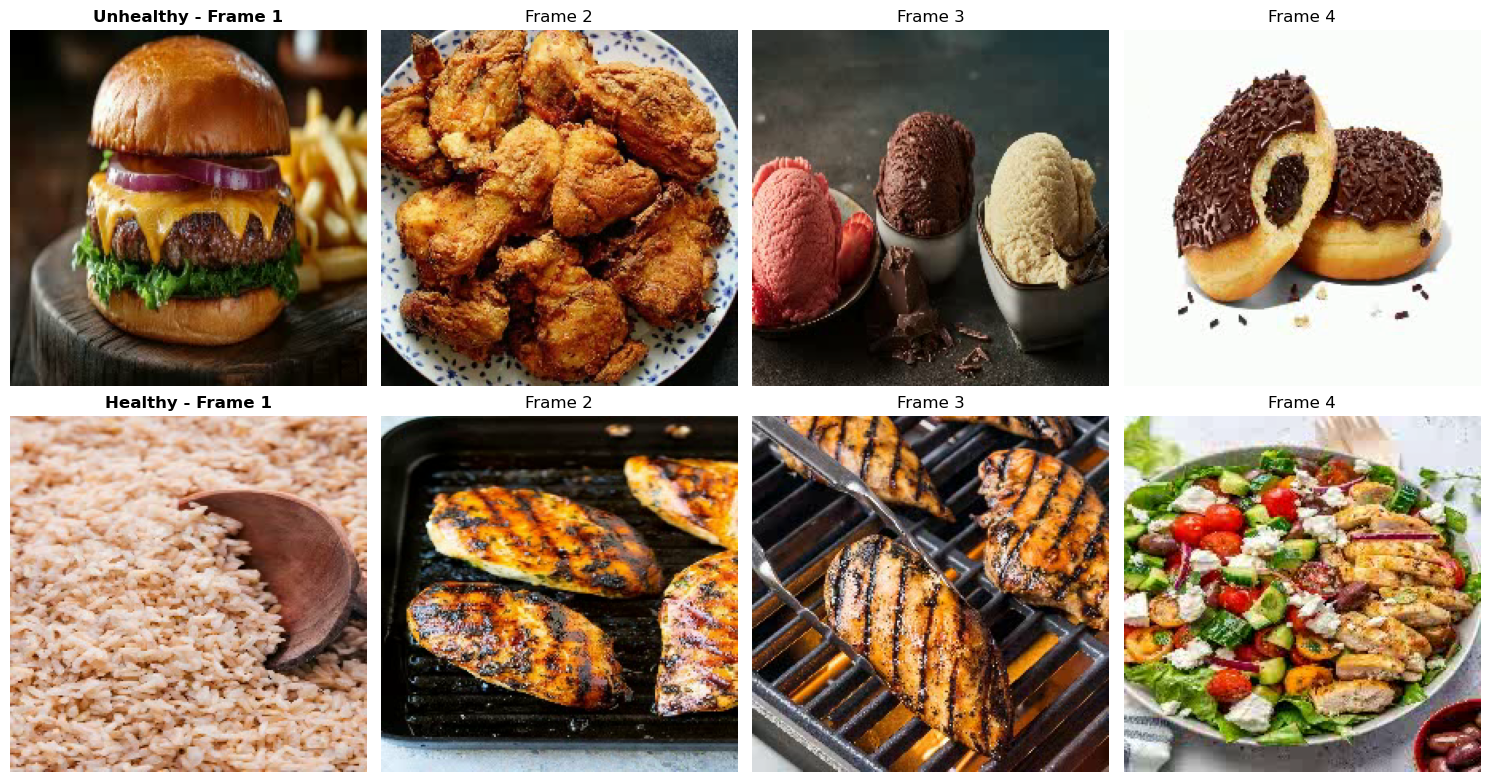

In [31]:
# Visualize sample videos
import matplotlib.pyplot as plt

# Get one batch from train loader
videos, labels_batch = next(iter(train_loader))
print(f"Batch shape: {videos.shape}")  # (batch_size, num_frames, 3, H, W)

# Visualize frames from first video in batch
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
label_names = ['Healthy', 'Unhealthy']

for i in range(2):  # Show 2 videos
    if i >= videos.shape[0]:
        break
    video = videos[i]  # (num_frames, 3, H, W)
    label = labels_batch[i].item()
    for j in range(4):  # Show 4 frames
        ax = axes[i, j]
        frame = video[j].permute(1, 2, 0).numpy()  # (H, W, 3)
        # Denormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        frame = frame * std + mean
        frame = np.clip(frame, 0, 1)
        ax.imshow(frame)
        ax.axis('off')
        if j == 0:
            ax.set_title(f'{label_names[label]} - Frame {j+1}', fontweight='bold')
        else:
            ax.set_title(f'Frame {j+1}')
plt.tight_layout()
plt.show()

In [32]:
# Training Setup

import torch.optim as optim
from tqdm import tqdm

# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
model = VideoViTClassifier(num_classes=2, pretrained=True, frames=8)
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("✓ Training setup complete!")

Using device: cpu
✓ Training setup complete!


In [33]:
# Training and Validation Functions

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train model for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for videos, labels in pbar:
        videos = videos.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * videos.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100 * correct / total:.1f}%'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    """Validate model on validation set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for videos, labels in tqdm(dataloader, desc='Validation', leave=False):
            videos = videos.to(device)
            labels = labels.to(device)
            
            outputs = model(videos)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * videos.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

print("✓ Training functions defined!")
print("  - train_epoch(): Train for one epoch with gradient clipping")
print("  - validate(): Evaluate on validation set")

✓ Training functions defined!
  - train_epoch(): Train for one epoch with gradient clipping
  - validate(): Evaluate on validation set


In [ ]:
# Train the model

NUM_EPOCHS = 10
best_val_acc = 0.0
best_val_loss = float('inf')
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Early stopping parameters
patience = 5
patience_counter = 0

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Update learning rate based on validation loss
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Learning Rate: {current_lr:.2e}")
    
    # Save best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'history': history
        }, 'best_food_classifier.pth')
        print(f"  ✓ New best model saved! (Val Acc: {best_val_acc:.2f}%)")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{patience}")
    
    # Early stopping check
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs!")
        break

print("TRAINING COMPLETE!")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print("Model saved to: best_food_classifier.pth")

Starting training for 10 epochs...
Device: cpu
Model parameters: 85,800,194

Epoch 1/10


Training:   0%|          | 0/16 [00:00<?, ?it/s]

Training: 100%|██████████| 16/16 [19:31<00:00, 73.19s/it, loss=0.0183, acc=62.5%]



Epoch 1 Summary:
  Train Loss: 1.4376 | Train Acc: 62.50%
  Val Loss:   1.0701 | Val Acc:   66.67%
  Learning Rate: 1.00e-04
  ✓ New best model saved! (Val Acc: 66.67%)

Epoch 2/10


Training: 100%|██████████| 16/16 [15:44<00:00, 59.04s/it, loss=0.1226, acc=71.9%]


...

Training: 100%|██████████| 16/16 [09:14<00:00, 34.69s/it, loss=0.0005, acc=96.9%] 



Epoch 5 Summary:
  Train Loss: 0.0800 | Train Acc: 96.88%
  Val Loss:   0.0816 | Val Acc:   100.00%
  Learning Rate: 1.00e-04
  No improvement. Patience: 1/5

Epoch 6/10


Training: 100%|██████████| 16/16 [08:46<00:00, 32.90s/it, loss=0.0009, acc=100.0%]



Epoch 6 Summary:
  Train Loss: 0.0192 | Train Acc: 100.00%
  Val Loss:   0.2543 | Val Acc:   88.89%
  Learning Rate: 1.00e-04
  No improvement. Patience: 2/5

Epoch 7/10


Training:  25%|██▌       | 4/16 [01:49<05:45, 28.83s/it, loss=0.0000, acc=100.0%]

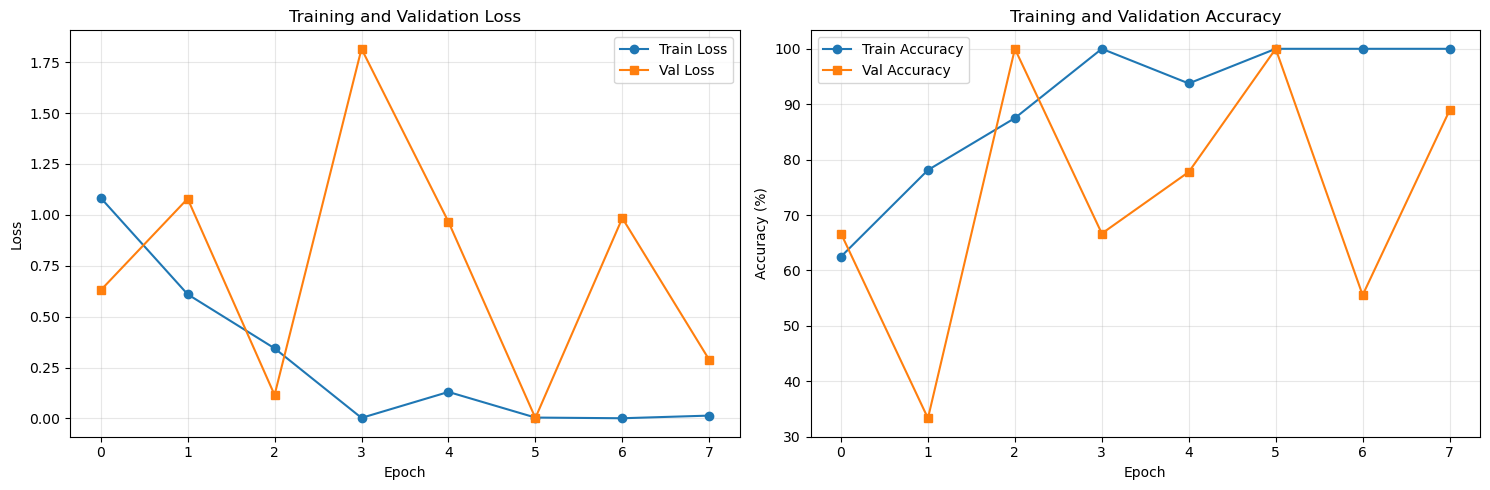

In [ ]:
# Plot training history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['val_acc'], label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Loaded model from epoch 2
Validation accuracy: 100.00%

INFERENCE TEST ON VALIDATION SAMPLES

✓ Video: healthy_6.mp4
   Prediction: Healthy (99.8% confidence)
   True Label: Healthy

✓ Video: Baked_Potato_healthy_1.mp4
   Prediction: Healthy (89.5% confidence)
   True Label: Healthy

✓ Video: unhealthy_2.mp4
   Prediction: Unhealthy (71.2% confidence)
   True Label: Unhealthy


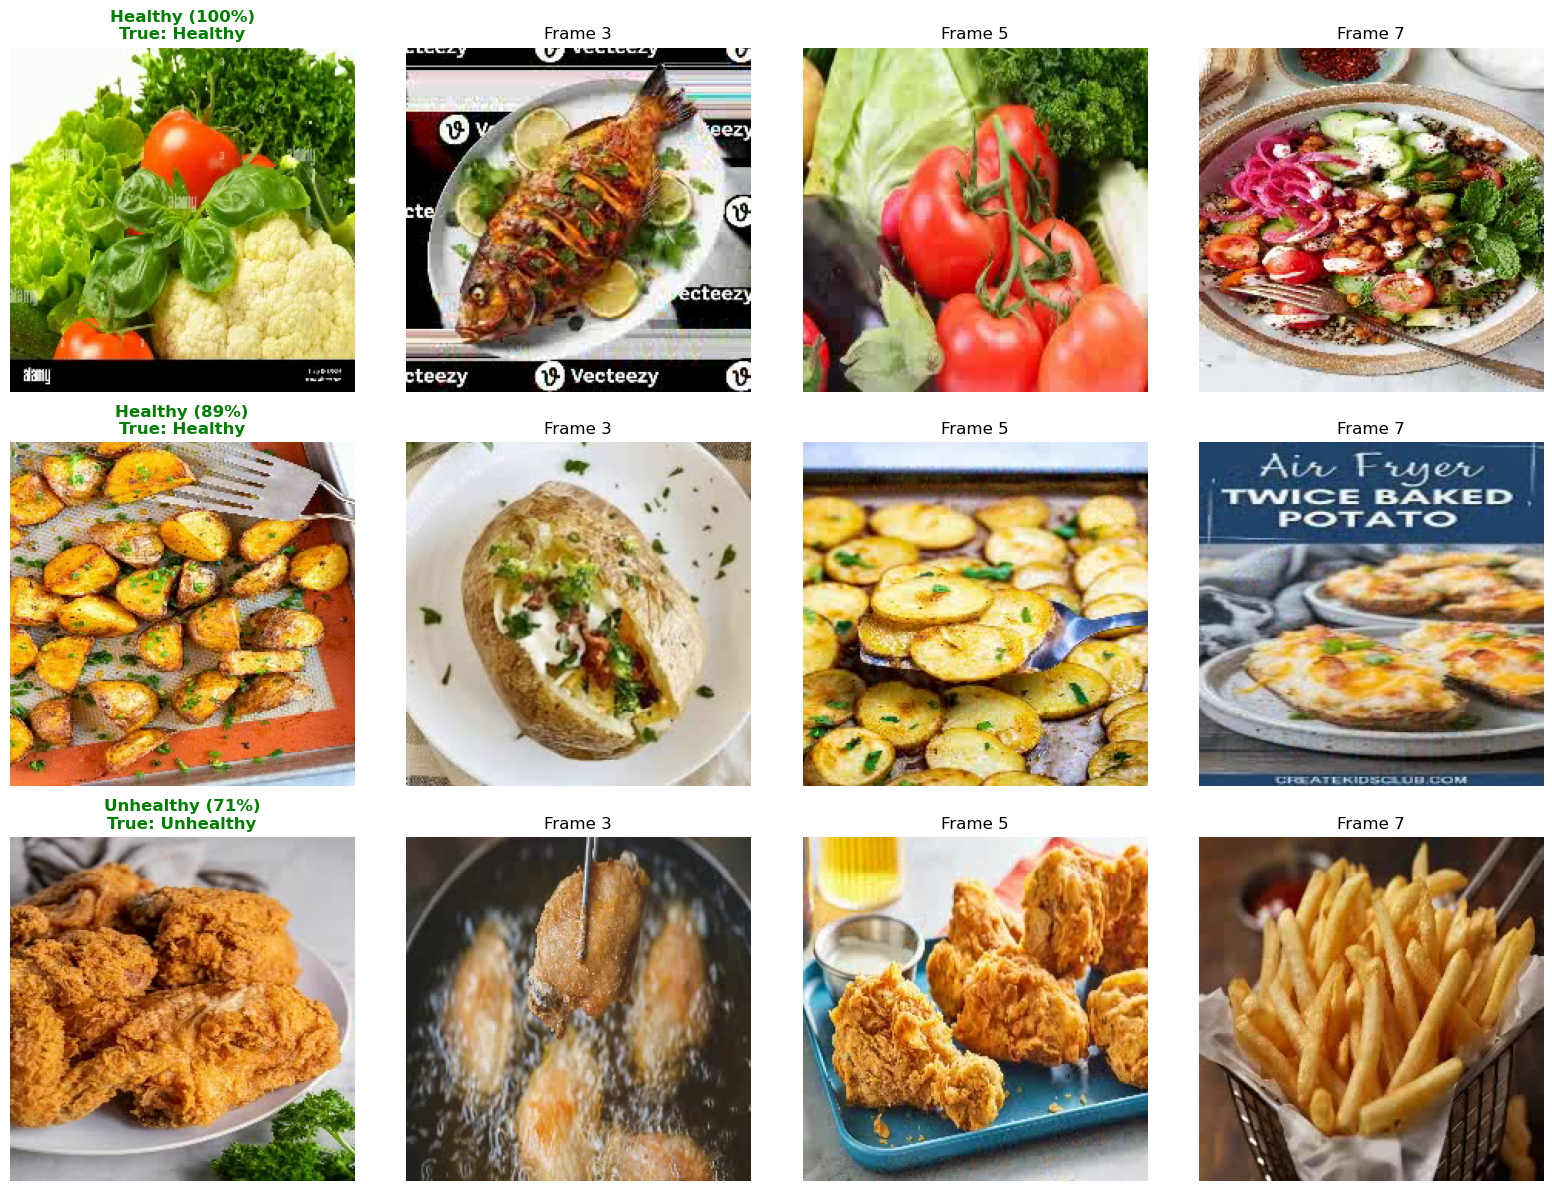

In [ ]:
# Inference on new videos

def predict_video(model, video_path, device, num_frames=8, img_size=224):
    """
    Predict whether a video contains healthy or unhealthy food.
    
    Args:
        model: Trained VideoViTClassifier model
        video_path: Path to the video file
        device: torch device (cuda/cpu)
        num_frames: Number of frames to sample
        img_size: Image size for model input
    
    Returns:
        prediction: 'Healthy' or 'Unhealthy'
        confidence: Confidence score (0-1)
        frames: List of sampled frames
    """
    model.eval()
    
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'Failed to open video: {video_path}')
    
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames < 1:
        cap.release()
        raise RuntimeError(f'Video has no frames: {video_path}')
    
    # Sample frames uniformly or with replacement if video is short
    if total_frames < num_frames:
        frame_indices = np.random.choice(total_frames, num_frames, replace=True)
    else:
        frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frames.append(frame)
        else:
            frames.append(np.zeros((img_size, img_size, 3), dtype=np.uint8))
    cap.release()
    
    # Transform frames
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                             std=[0.229, 0.224, 0.225])
    ])
    
    transformed_frames = [transform(frame) for frame in frames]
    video_tensor = torch.stack(transformed_frames).unsqueeze(0).to(device)
    
    # Inference
    with torch.no_grad():
        outputs = model(video_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_class].item()
    
    label_names = ['Healthy', 'Unhealthy']
    return label_names[predicted_class], confidence, frames

# Load best model checkpoint
checkpoint = torch.load('best_food_classifier.pth', weights_only=False)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model from epoch {checkpoint.get('epoch', 'unknown')}")
    print(f"Validation accuracy: {checkpoint.get('val_acc', 'unknown'):.2f}%")
else:
    # Handle legacy format (just state dict)
    model.load_state_dict(checkpoint)
    print("Loaded model (legacy format)")

model.eval()

# Test inference on validation videos
print("\n" + "="*60)
print("INFERENCE TEST ON VALIDATION SAMPLES")
print("="*60)

num_samples = min(3, len(val_paths))
fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
if num_samples == 1:
    axes = axes.reshape(1, -1)

for sample_idx in range(num_samples):
    test_video_path = val_paths[sample_idx]
    true_label = 'Healthy' if val_labels[sample_idx] == 0 else 'Unhealthy'
    
    try:
        prediction, confidence, frames = predict_video(model, test_video_path, device)
        is_correct = (prediction == true_label)
        status = "✓" if is_correct else "✗"
        
        print(f"\n{status} Video: {test_video_path.name}")
        print(f"   Prediction: {prediction} ({confidence*100:.1f}% confidence)")
        print(f"   True Label: {true_label}")
        
        # Visualize frames
        for j in range(4):
            ax = axes[sample_idx, j]
            ax.imshow(frames[j*2])  # Show every other frame
            ax.axis('off')
            if j == 0:
                color = 'green' if is_correct else 'red'
                ax.set_title(f'{prediction} ({confidence*100:.0f}%)\nTrue: {true_label}', 
                           fontweight='bold', color=color)
            else:
                ax.set_title(f'Frame {j*2+1}')
                
    except Exception as e:
        print(f"Error processing {test_video_path}: {e}")

plt.tight_layout()
plt.show()

Loaded model from epoch 3
Checkpoint val accuracy: 100.00%

Evaluating model on validation set...


Evaluating: 100%|██████████| 5/5 [00:34<00:00,  6.88s/it]


EVALUATION RESULTS
Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%
F1-Score:  100.00%

Confusion Matrix (counts):
           Healthy  Unhealthy
Healthy          3          0
Unhealthy        0          6


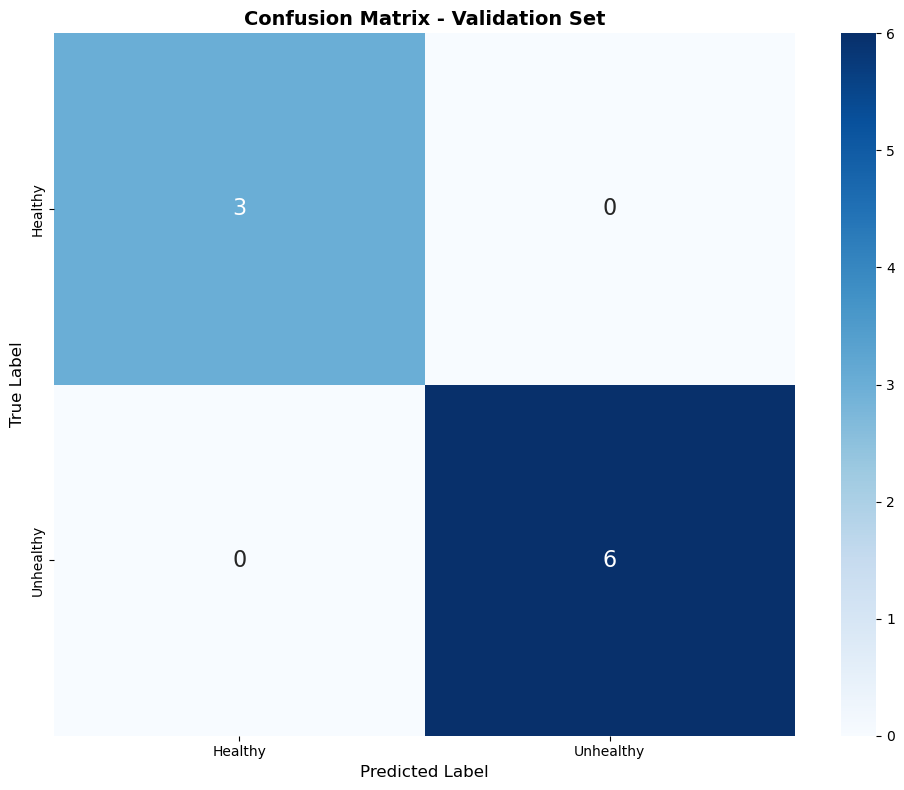

PER-CLASS METRICS
              precision    recall  f1-score   support

     Healthy     1.0000    1.0000    1.0000         3
   Unhealthy     1.0000    1.0000    1.0000         6

    accuracy                         1.0000         9
   macro avg     1.0000    1.0000    1.0000         9
weighted avg     1.0000    1.0000    1.0000         9


Confusion Matrix Breakdown (counts and % of total):
  True Healthy,    Predicted Healthy:   3 (33.3%) (True Negatives)
  True Healthy,    Predicted Unhealthy: 0 (0.0%) (False Positives)
  True Unhealthy,  Predicted Healthy:   0 (0.0%) (False Negatives)
  True Unhealthy,  Predicted Unhealthy: 6 (66.7%) (True Positives)


In [ ]:
# Detailed evaluation metrics

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support
import seaborn as sns
import pandas as pd

def evaluate_model(model, dataloader, device):
    """Get predictions and labels for entire dataset"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for videos, labels in tqdm(dataloader, desc='Evaluating'):
            videos = videos.to(device)
            labels = labels.to(device)
            
            outputs = model(videos)
            probabilities = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probabilities.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Load best model for evaluation
checkpoint = torch.load('best_food_classifier.pth', weights_only=False)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded model from epoch {checkpoint.get('epoch', 'unknown') + 1}")
    print(f"Checkpoint val accuracy: {checkpoint.get('val_acc', 0):.2f}%")
else:
    # Handle legacy format
    model.load_state_dict(checkpoint)
    print("Loaded model (legacy format)")

model.eval()

# Evaluate on validation set
print("\nEvaluating model on validation set...")
val_preds, val_labels_array, val_probs = evaluate_model(model, val_loader, device)

# Calculate metrics
accuracy = accuracy_score(val_labels_array, val_preds)
precision, recall, f1, _ = precision_recall_fscore_support(val_labels_array, val_preds, average='weighted')

print("EVALUATION RESULTS")
print(f"{'='*60}")
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1-Score:  {f1*100:.2f}%")

# Confusion matrix
class_names = ['Healthy', 'Unhealthy']
cm = confusion_matrix(val_labels_array, val_preds, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix (counts):")
print(cm_df)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 16})
plt.title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class metrics
print("PER-CLASS METRICS")
print(f"{'='*60}")
print(classification_report(val_labels_array, val_preds, 
                          target_names=class_names,
                          digits=4))

# Show confusion matrix breakdown with percentages
print("\nConfusion Matrix Breakdown (counts and % of total):")
total = cm.sum()
def fmt_count_pct(value, total_value):
    pct = (value / total_value * 100) if total_value else 0
    return f"{value} ({pct:.1f}%)"
print(f"  True Healthy,    Predicted Healthy:   {fmt_count_pct(cm[0][0], total)} (True Negatives)")
print(f"  True Healthy,    Predicted Unhealthy: {fmt_count_pct(cm[0][1], total)} (False Positives)")
print(f"  True Unhealthy,  Predicted Healthy:   {fmt_count_pct(cm[1][0], total)} (False Negatives)")
print(f"  True Unhealthy,  Predicted Unhealthy: {fmt_count_pct(cm[1][1], total)} (True Positives)")

In [ ]:
# Model Summary and Export

print("MODEL SUMMARY")

# Model architecture info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Model type:           VideoViTClassifier (ViT-B/16 backbone)")
print(f"Input:                (batch, {model.frames} frames, 3, 224, 224)")
print("Output:               (batch, 2) - [Healthy, Unhealthy]")

# Training summary
print("\nTraining Summary:")
print(f"  Epochs trained:     {len(history['train_loss'])}")
print(f"  Best Val Accuracy:  {max(history['val_acc']):.2f}%")
print(f"  Final Train Acc:    {history['train_acc'][-1]:.2f}%")
print(f"  Final Val Acc:      {history['val_acc'][-1]:.2f}%")

# Save final model in multiple formats
print("\nSaved artifacts:")
print("  ✓ best_food_classifier.pth (full checkpoint)")

# Export just the model weights for inference
torch.save(model.state_dict(), 'food_classifier_weights.pth')
print("  ✓ food_classifier_weights.pth (weights only)")

print("Training pipeline complete!")

MODEL SUMMARY
Total parameters:     85,800,194
Trainable parameters: 85,800,194
Model type:           VideoViTClassifier (ViT-B/16 backbone)
Input:                (batch, 8 frames, 3, 224, 224)
Output:               (batch, 2) - [Healthy, Unhealthy]

Training Summary:
  Epochs trained:     8
  Best Val Accuracy:  100.00%
  Final Train Acc:    100.00%
  Final Val Acc:      88.89%

Saved artifacts:
  ✓ best_food_classifier.pth (full checkpoint)
  ✓ food_classifier_weights.pth (weights only)
Training pipeline complete!
